In [1]:
import os
import sys
from pathos.pools import ProcessPool
sys.path.append('/Users/leonardo.tessarolo/git/bayesian_bss/')

import numpy as np
import math
import pandas as pd
from numpyro.diagnostics import gelman_rubin

from matplotlib import pyplot as plt

from src import PosteriorUtilities, StandardLogisticSource, ExponentialPrior
np.random.seed(100)

# 1. Definir classe

In [2]:
class MMSEMetropolisHastingsEstimator:
    
    def __init__(
        self,
        n_samples: int,
        source_pdf_fn,
        prior_pdf_fn,
        exploration_var,
        parallel_chains,
        max_it,
        R_hat_thresh=1.01,
        R_hat_evaluation_step=100,
        R_hat_persistance=5,
        R_hat_minimum_burn_in=1000
    ):
        self.n_samples=n_samples
        self.log_posterior_fn=PosteriorUtilities.get_log_posterior_fn(
            source_pdf_fn=source_pdf_fn,
            prior_pdf_fn=prior_pdf_fn
        )
        self.Q=self.__get_Q(
            exploration_var=exploration_var
        )
        self.R_hat_thresh=R_hat_thresh
        self.parallel_chains=parallel_chains
        self.max_it=max_it
        self.n_samples_per_chain = n_samples//parallel_chains
        self.R_hat_minimum_evaluation=R_hat_minimum_burn_in + self.n_samples_per_chain
        self.R_hat_persistance=R_hat_persistance
        self.R_hat_evaluation_step=R_hat_evaluation_step
    

    def __get_Q(
        self,
        exploration_var
    ):
        """
            This method obtains the Q function for metropolis-hastings algorithm. The Q function takes in a current value
            of the estimated parameters and proposes a new one.
        """
        def __proposal_fn(
            exploration_var,
            B
        ):
            # Calculate shift in parameter
            shift = np.random.normal(
                loc=0,
                scale=np.sqrt(exploration_var),
                size=B.shape
            )
        
            # Sum shift to obtain new parameter value
            new_B = np.add(
                B, shift
            )
        
            return new_B

        return lambda B: __proposal_fn(
            exploration_var=exploration_var,
            B=B
        )
    
    
    def fit(
        self,
        x,
        initial_condition
    ):
        
        def __get_samples(
            log_posterior_fn,
            x,
            n_samples: int,
            initial_value,
            chain
        ):
            
            # Number of observations and sources
            NOBS=x.shape[-1]
            NSOURCES=x.shape[0]

            # Inicialização aleatória de B
            B = initial_value
            logs = pd.DataFrame()

            max_posterior = -np.inf
            n=1
            MH_samples = []
            last_B = initial_value
            new_B = None
            logs = pd.DataFrame()
            for i in range(n_samples):
                
                # Get new B
                new_B = self.Q(last_B)
                
                # Get proposal alpha
                alpha_proposal = log_posterior_fn(x, new_B) - log_posterior_fn(x, last_B)
                
                # Check whether it is greater than 0 and anti-transform alpha to yield a probability
                alpha = 1 if alpha_proposal > 0 else np.exp(alpha_proposal)
            
                # Get random uniform sample and check whether it is smaller than alpha. This will
                # say if new sample is accepted
                choice_sample = np.random.uniform(0,1)
                save_new_sample = choice_sample < alpha
                
                # Save new sample or current one
                if save_new_sample:
                    MH_samples.append(new_B)
                    last_B=new_B
                else:
                    MH_samples.append(last_B)

                # Save to log
                logs = pd.concat(
                    [
                        logs,
                        pd.DataFrame(
                            index=[i],
                            data={
                                'inside_iteration': [i+1],
                                'B_sample': [last_B],
                                'alpha': [alpha],
                                'save_new_sample': [save_new_sample],
                                'log_posterior': [log_posterior_fn(x, last_B)/NOBS]
                            }
                        )
                    ]
                )
            
            logs['chain'] = chain
            
            return np.array(MH_samples), logs
        
        def __get_R_hats(
            samples,
            iteration
        ):
            iteration_samples = samples[0].shape[0]
            r_hats = {'iteration': [iteration]}
            for i,j in np.ndindex((samples[0].shape[-2], samples[0].shape[-1])):
                # Get samples across chains for coefficient ij
                bij_samples = np.array([
                    samples[c][:,i,j] for c in range(self.parallel_chains)
                ])

                # Evaluate r-hat
                r_hats['b_{}{}'.format(i+1, j+1)] = [gelman_rubin(x=bij_samples)]

            return pd.DataFrame(
                index=[0],
                data=r_hats
            )
        

        def __get_next_iteration(
            R_hats,
            it
        ):

            # Evaluate persistance
            if R_hats.shape[0] < self.R_hat_persistance:
                stop=False
            # If at least R_hat_persistance evaluations held:
            else:
                if it < self.max_it:
                    # Evaluate if all R_hats converged for R_hat_persistance evaluations
                    if np.all(
                        R_hats.drop(
                            columns=['iteration']
                        ).values[-self.R_hat_persistance,:] < self.R_hat_thresh
                    ):
                        stop=True
                        self.converged=True
                    else:
                        stop=False
                # Evaluate maximum iterations
                else:
                    stop=True
                    self.converged=False

            # Increment iteration
            if not stop:
                it += self.R_hat_evaluation_step

            return stop, it
            


        def __parse_MCMC_results(
            chains_samples,
            R_hats,
            logs 
        ):
            
            # Merge samples from different chains into one vector
            merged_samples = np.concatenate(
                [
                    s[-self.n_samples_per_chain:,:,:] for s in chains_samples
                ],
                axis=0
            )

            # Get index for which maximum posterior was found
            max_posterior_idx = logs[
                logs.iteration > logs.iteration.max() - self.n_samples_per_chain
            ].log_posterior.idxmax()

            # Get max posterior sample and index
            max_posterior = logs.loc[max_posterior_idx]['log_posterior']
            max_posterior_B = logs.loc[max_posterior_idx]['B_sample']

            # Get Monte Carlo MMSE estimate
            B_est_mmse = np.mean(
                merged_samples,
                axis=0
            )

            # Average alpha in stationarity
            average_alpha = logs[
                logs.iteration > logs.iteration.max() - self.n_samples_per_chain
            ].alpha.mean()

            # Store parsed results
            parsed_results = {
                'samples': merged_samples,
                'R_hats': R_hats,
                'logs': logs,
                'B_est': B_est_mmse,
                'max_posterior': max_posterior,
                'max_posterior_B': max_posterior_B,
                'average_alpha': average_alpha
            }

            # Save parsed results
            self.mcmc_results = parsed_results


        # Run initial period (minimum R-hat evaluation samples)
        results_minimum_eval = [
            __get_samples(
                log_posterior_fn=self.log_posterior_fn,
                x=x,
                n_samples=self.R_hat_minimum_evaluation,
                initial_value=B0,
                chain=c
            ) for c, B0 in zip(
                range(self.parallel_chains), 
                initial_condition
            )
        ]

        # Append samples
        samples = np.array([
            tup[0] for tup in results_minimum_eval
        ])

        # Append logs
        logs = pd.concat(
            [
                tup[-1] for tup in results_minimum_eval
            ],
            axis=0
        )

        # Get R-hats
        R_hats = __get_R_hats(
            samples=np.array([
                samples_chain[-self.n_samples_per_chain:,:,:] for samples_chain in samples
            ]),
            iteration=self.R_hat_minimum_evaluation
        )

        # Run loop
        it = self.R_hat_minimum_evaluation + self.R_hat_evaluation_step
        stopping_condition=False
        while not stopping_condition:
            # Run incremental period for evaluating R-hat
            results_incremental_eval = [
                __get_samples(
                    log_posterior_fn=self.log_posterior_fn,
                    x=x,
                    n_samples=self.R_hat_evaluation_step,
                    initial_value=samples[c][-1,:,:],
                    chain=c
                ) for c in range(self.parallel_chains)
            ]

            # Append samples
            samples_incremental = np.array([
                tup[0] for tup in results_incremental_eval
            ])
            samples = np.array([
                np.concatenate(
                    [
                        s,
                        s_inc
                    ],
                    axis=0
                ) for s, s_inc in zip(
                    samples, samples_incremental
                )
            ])

            # Append logs
            logs_incremental = pd.concat(
                [
                    tup[-1] for tup in results_incremental_eval
                ],
                axis=0
            )
            logs = pd.concat(
                [
                    logs,
                    logs_incremental
                ],
                axis=0
            ).reset_index(
                drop=True
            )

            # Get R-hats
            R_hats = pd.concat(
                [
                    R_hats,
                    __get_R_hats(
                        samples=np.array([
                            samples_chain[-self.n_samples_per_chain:,:,:] for samples_chain in samples
                        ]),
                        iteration=it
                    )
                ]               
            ).reset_index(
                drop=True
            )

            # Evaluate next iteration
            stopping_condition, it = __get_next_iteration(
                R_hats=R_hats,
                it=it
            )

        # Get iterations per chain
        logs['iteration'] = logs.groupby(
            by='chain'
        ).cumcount() + 1
        

        # Parse results
        __parse_MCMC_results(
            chains_samples=samples,
            R_hats=R_hats,
            logs=logs
        )

        self.samples=samples
        self.R_hats=R_hats
        self.logs=logs

        return samples, R_hats, logs
        

# 2. Executar MCMC

Text(0, 0.5, 'count')

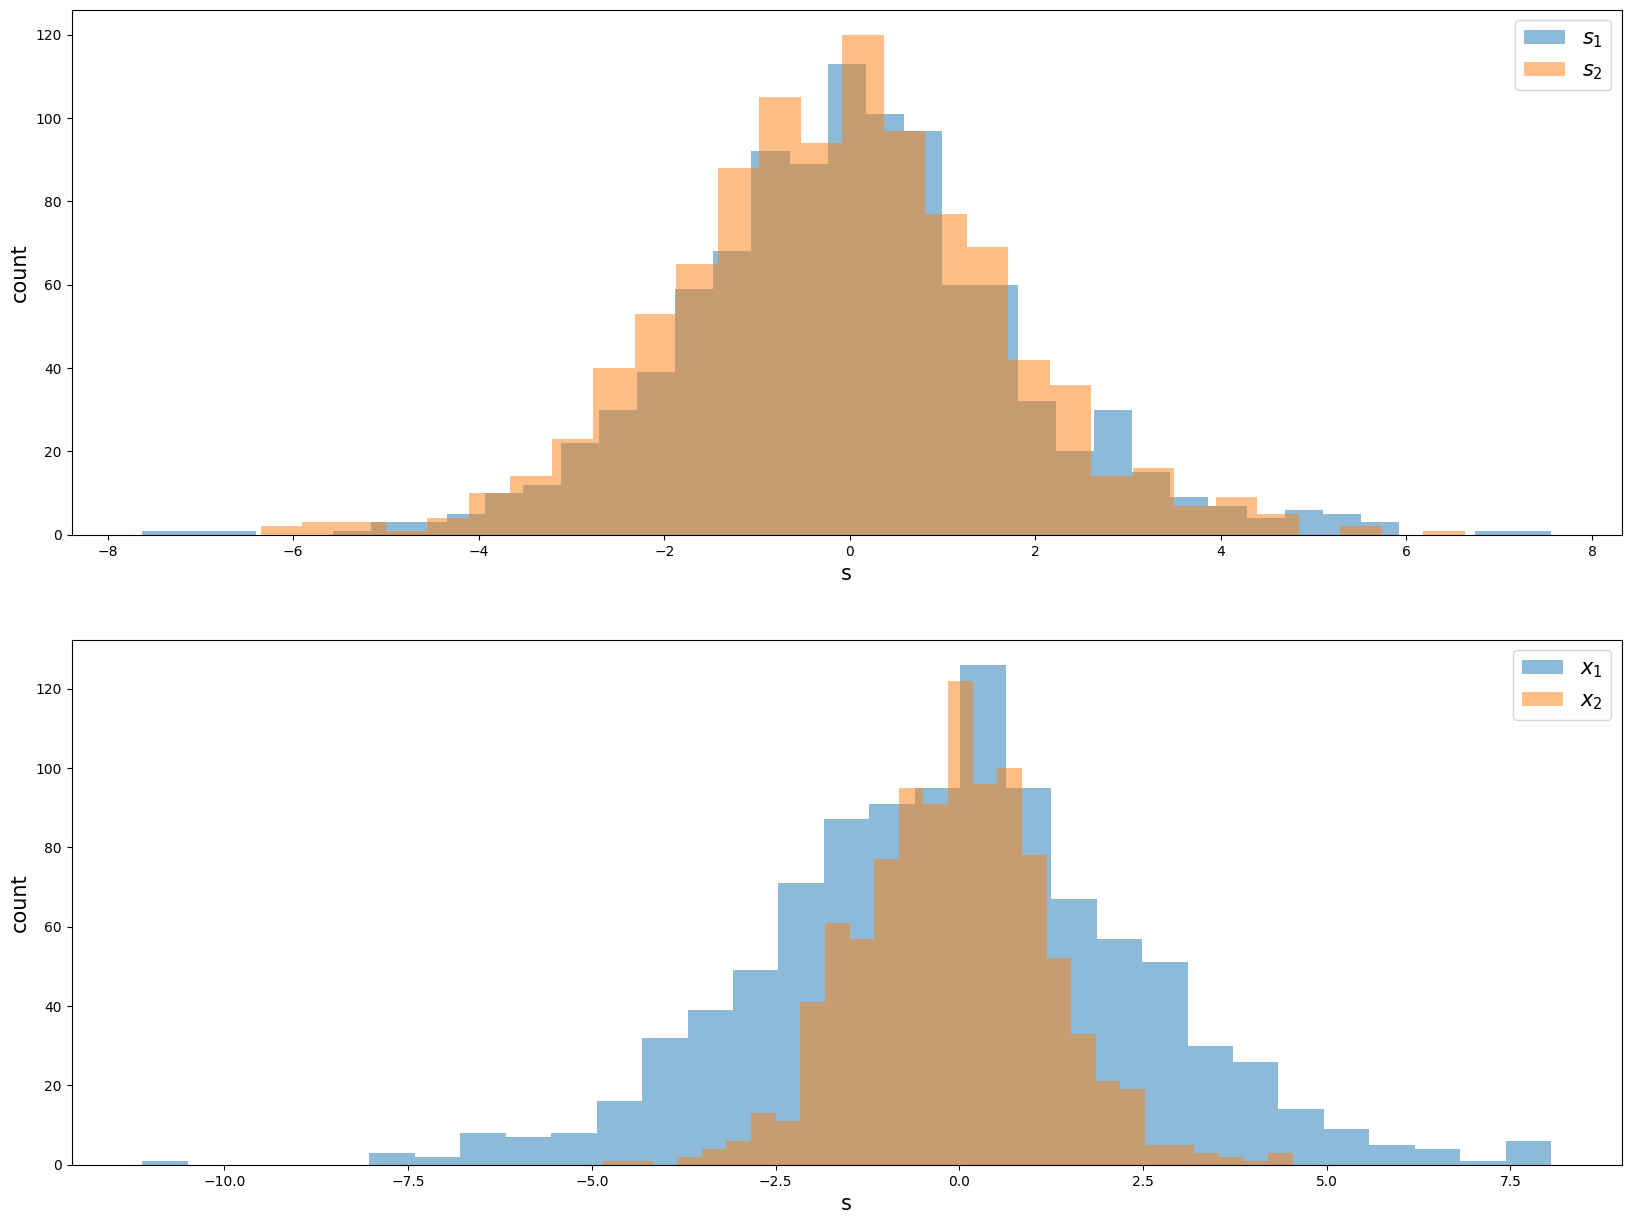

In [3]:
# Number of sources and observations
NSOURCES=2
NOBS=1000

# Mixing matrix configuration
A = np.array([
    [1, 1],
    [-0.5, 0.5]
])

# Ideal separation matrix
B = np.linalg.inv(A)

# Get source realization
s = StandardLogisticSource().get_realization(
    nsources=NSOURCES,
    nobs=NOBS,
    seed=100
)
# Get mixtures
x = A@s

# Plot
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1, figsize=(20,15)
)

# Ax1
ax1.hist(
    s[0,:],
    bins='fd',
    label='$s_{1}$',
    alpha=0.5
)
ax1.hist(
    s[1,:],
    bins='fd',
    label='$s_{2}$',
    alpha=0.5
)
ax1.legend(fontsize=15)
ax1.set_xlabel(
    's',
    fontsize=15
)
ax1.set_ylabel(
    'count',
    fontsize=15
)

# Ax2
ax2.hist(
    x[0,:],
    bins='fd',
    label='$x_{1}$',
    alpha=0.5
)
ax2.hist(
    x[1,:],
    bins='fd',
    label='$x_{2}$',
    alpha=0.5
)
ax2.legend(fontsize=15)
ax2.set_xlabel(
    's',
    fontsize=15
)
ax2.set_ylabel(
    'count',
    fontsize=15
)

In [4]:
N_SAMPLES=20000
EXPLORATION_VAR = 1E-3
PARALLEL_CHAINS=4
R_HAT_THRESH=1.01
R_HAT_MINIMUM_BURN_IN=1000
R_HAT_EVALUATION_STEP=50
R_HAT_PERSISTANCE=10
MAX_IT=30000

# Source model pdf
source_pdf = StandardLogisticSource().get()

# Prior pdf
prior_pdf = ExponentialPrior(
    center=B,
    std=1
).get()

# Initial conditions
initial_condition = [
    np.random.uniform(
        low=-2,
        high=2,
        size=B.shape
    ) for c in range(PARALLEL_CHAINS)
]

In [5]:
mmse = MMSEMetropolisHastingsEstimator(
    n_samples=N_SAMPLES,
    source_pdf_fn=source_pdf,
    prior_pdf_fn=prior_pdf,
    exploration_var=EXPLORATION_VAR,
    parallel_chains=PARALLEL_CHAINS,
    max_it=MAX_IT,
    R_hat_thresh=R_HAT_THRESH,
    R_hat_evaluation_step=R_HAT_EVALUATION_STEP,
    R_hat_persistance=R_HAT_PERSISTANCE,
    R_hat_minimum_burn_in=R_HAT_MINIMUM_BURN_IN
)

samples, R_hats, logs = mmse.fit(
    x=x,
    initial_condition=initial_condition
)
print('#'*100)
print('B estimado via MMSE:\n{}'.format(mmse.mcmc_results['B_est']))
print('#'*100)

####################################################################################################
B estimado via MMSE:
[[ 0.24522445 -0.53069977]
 [-0.24488093  0.50974704]]
####################################################################################################


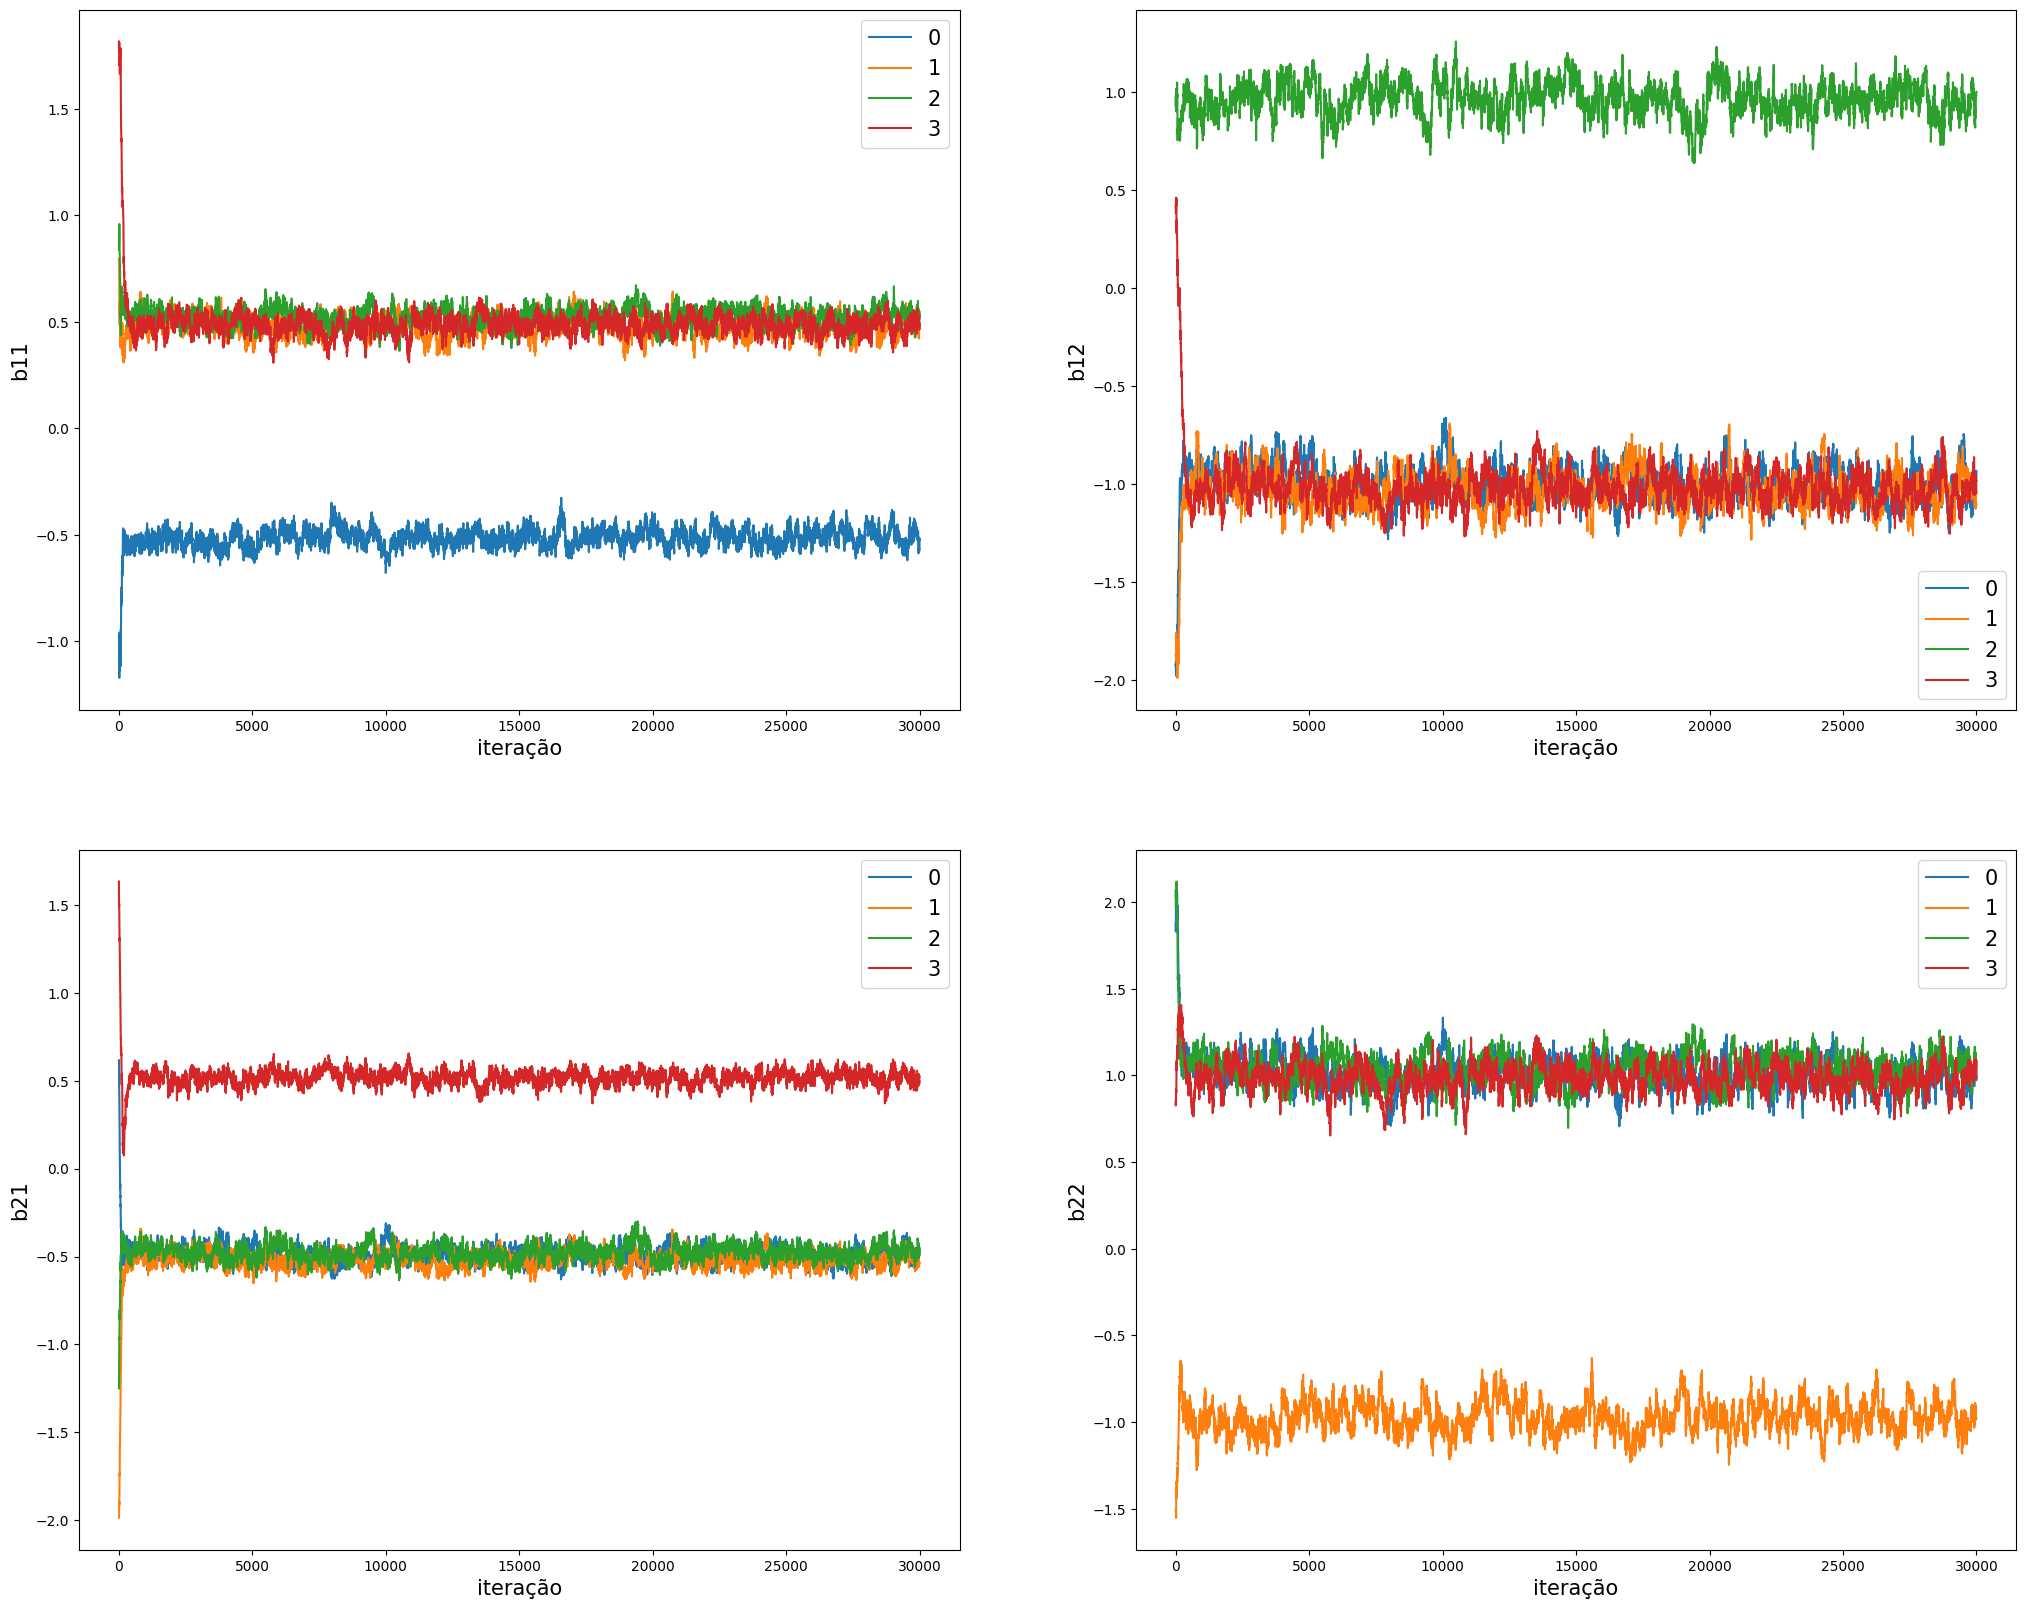

In [6]:
# Plot chain evolutions
fig, axs = plt.subplots(
    nrows=2, ncols=2,
    figsize=(25,20)
)

for i,j in np.ndindex(B.shape):
    for c in range(PARALLEL_CHAINS):
        axs[i,j].plot(
            samples[c][:,i,j],
            label=c
        )
    axs[i,j].legend(
        fontsize=15
    )
    axs[i,j].set_xlabel(
        'iteração',
        fontsize=15
    )
    axs[i,j].set_ylabel(
        'b{}{}'.format(
            i+1,
            j+1
        ),
        fontsize=15
    )

<>:33: SyntaxWarning: invalid escape sequence '\h'
<>:33: SyntaxWarning: invalid escape sequence '\h'
/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_29963/4273758196.py:33: SyntaxWarning: invalid escape sequence '\h'
  '$\hat{R}$',


,iteration,b_11,b_12,b_21,b_22
0,6000,12.639253,11.792601,11.842641,12.341044
1,6050,12.590768,11.750667,11.790850,12.318453
2,6100,12.570319,11.695374,11.789900,12.336509
3,6150,12.545623,11.661736,11.763966,12.305050
4,6200,12.496375,11.618609,11.719580,12.233341
...,...,...,...,...,...
476,29800,12.312946,12.787376,13.044149,12.513590
477,29850,12.283544,12.792382,13.042005,12.488063
478,29900,12.329855,12.838061,13.096920,12.534789
479,29950,12.346082,12.847811,13.111836,12.570127


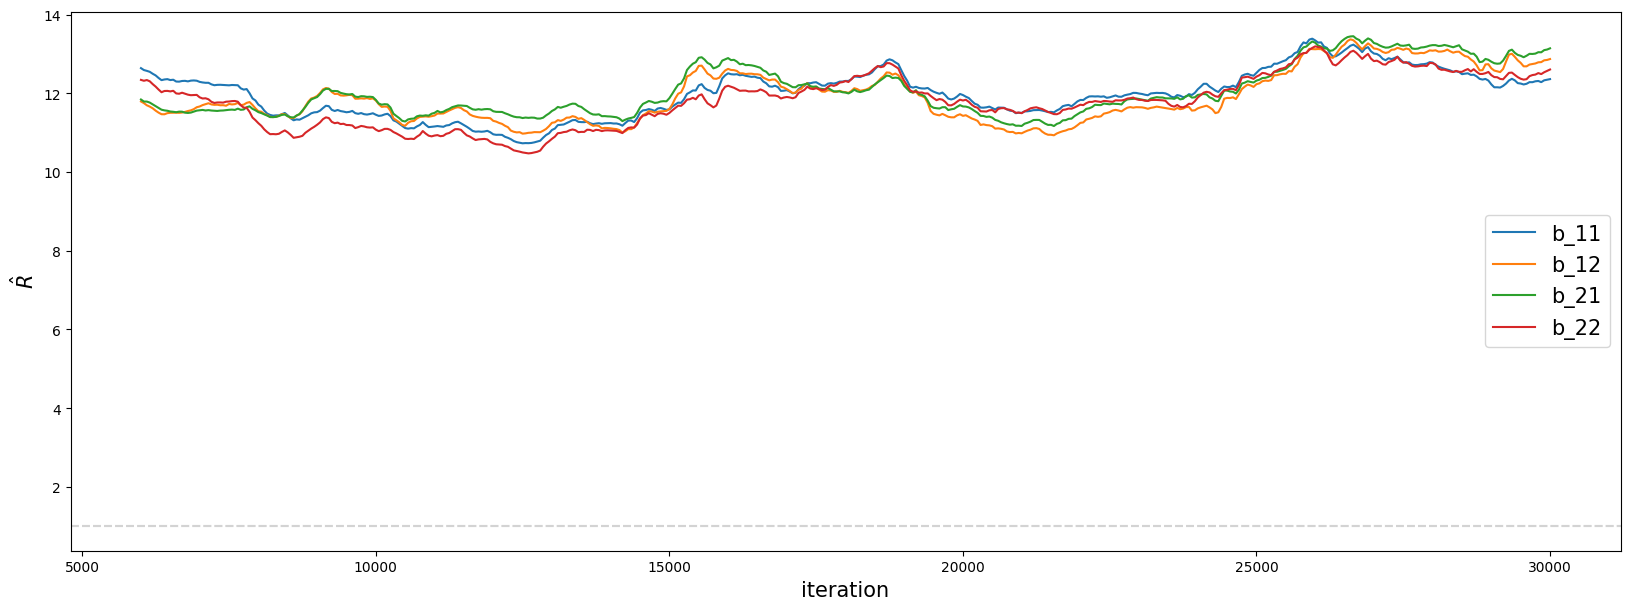

In [7]:
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(20,7)
)

for c in R_hats.drop(
    columns=['iteration']
).columns:
    ax.plot(
        R_hats.iteration,
        R_hats[c],
        label=c
    )

ax.axhline(
    1,
    c='lightgray',
    linestyle='--'
)

ax.axhline(
    R_HAT_THRESH,
    c='lightgray',
    linestyle='--'
)

ax.set_xlabel(
    'iteration',
    fontsize=15
)

ax.set_ylabel(
    '$\hat{R}$',
    fontsize=15
)

l=ax.legend(
    fontsize=15
)

R_hats

### MOSTRAR FASE TRANSITÓRIA

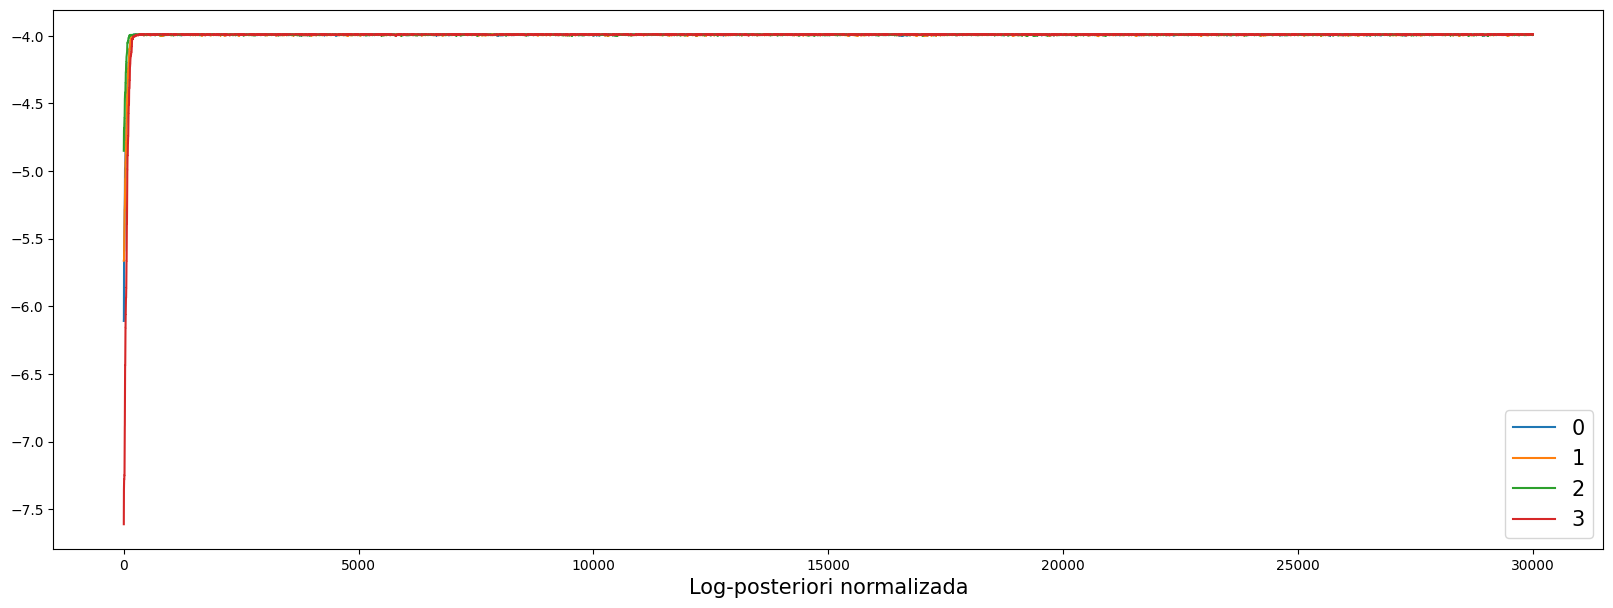

In [8]:
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(20,7)
)

for c, c_group in logs.groupby(by='chain'):
    ax.plot(
        c_group.iteration,
        c_group.log_posterior,
        label=c
    )
ax.set_xlabel(
    'iteration',
    fontsize=15
)
ax.set_xlabel(
    'Log-posteriori normalizada',
    fontsize=15
)
ax.legend(
    fontsize=15
)